# Importing

## Import Library

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/guriya79/fertility-dataset/Fertility_Health_Dataset_2026.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('/kaggle/input/datasets/guriya79/fertility-dataset/Fertility_Health_Dataset_2026.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,Couple_ID,Female_Age,Male_Age,BMI,Menstrual_Regularity,PCOS,Stress_Level,Smoking,Alcohol_Intake,Sperm_Count_Million_per_ml,Motility_%,Trying_Duration_Months,Treatment_Type,Pregnancy_Outcome
0,1,26,35,22.6,Regular,No,High,No,NaN,75.7,74.1,13,NaN,Success
1,2,39,30,28.0,Regular,No,High,Yes,Moderate,25.2,27.4,35,NaN,Failure
2,3,34,35,24.1,Regular,Yes,Low,No,High,64.0,74.5,13,NaN,Success
3,4,30,22,19.6,Regular,No,High,No,High,87.3,31.9,31,NaN,Success
4,5,27,40,33.6,Irregular,No,Low,No,High,116.9,51.3,21,Medication,Success


## last Five row

In [4]:
df.tail()

,Couple_ID,Female_Age,Male_Age,BMI,Menstrual_Regularity,PCOS,Stress_Level,Smoking,Alcohol_Intake,Sperm_Count_Million_per_ml,Motility_%,Trying_Duration_Months,Treatment_Type,Pregnancy_Outcome
795,796,29,39,28.4,Regular,No,High,No,Moderate,109.5,34.0,27,NaN,Success
796,797,29,26,19.1,Regular,Yes,Low,No,NaN,74.5,70.1,28,NaN,Success
797,798,38,33,26.8,Irregular,No,High,Yes,NaN,65.7,42.0,16,NaN,Success
798,799,36,33,20.6,Irregular,No,High,No,High,69.1,41.4,33,NaN,Failure
799,800,40,40,30.5,Irregular,No,Medium,No,Moderate,117.5,30.7,19,NaN,Failure


## Shape of our dataset

In [5]:
df.shape

(800, 14)

## List out all columns

In [6]:
df.columns

Index(['Couple_ID', 'Female_Age', 'Male_Age', 'BMI', 'Menstrual_Regularity',
       'PCOS', 'Stress_Level', 'Smoking', 'Alcohol_Intake',
       'Sperm_Count_Million_per_ml', 'Motility_%', 'Trying_Duration_Months',
       'Treatment_Type', 'Pregnancy_Outcome'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Couple_ID                       int64
Female_Age                      int64
Male_Age                        int64
BMI                           float64
Menstrual_Regularity           object
PCOS                           object
Stress_Level                   object
Smoking                        object
Alcohol_Intake                 object
Sperm_Count_Million_per_ml    float64
Motility_%                    float64
Trying_Duration_Months          int64
Treatment_Type                 object
Pregnancy_Outcome              object
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Couple_ID                   800 non-null    int64  
 1   Female_Age                  800 non-null    int64  
 2   Male_Age                    800 non-null    int64  
 3   BMI                         800 non-null    float64
 4   Menstrual_Regularity        800 non-null    object 
 5   PCOS                        800 non-null    object 
 6   Stress_Level                800 non-null    object 
 7   Smoking                     800 non-null    object 
 8   Alcohol_Intake              541 non-null    object 
 9   Sperm_Count_Million_per_ml  800 non-null    float64
 10  Motility_%                  800 non-null    float64
 11  Trying_Duration_Months      800 non-null    int64  
 12  Treatment_Type              300 non-null    object 
 13  Pregnancy_Outcome           800 non

## Check Null Value

In [9]:
df.isnull().sum()

Couple_ID                       0
Female_Age                      0
Male_Age                        0
BMI                             0
Menstrual_Regularity            0
PCOS                            0
Stress_Level                    0
Smoking                         0
Alcohol_Intake                259
Sperm_Count_Million_per_ml      0
Motility_%                      0
Trying_Duration_Months          0
Treatment_Type                500
Pregnancy_Outcome               0
dtype: int64

## Drop Alcohol_Intake and Treatment_Type Column

In [10]:
df.drop(columns=['Alcohol_Intake', 'Treatment_Type'], inplace=True)

## Check Dupicate Value

In [11]:
df.duplicated().sum()

np.int64(0)

## Summary

In [12]:
df.describe()

,Couple_ID,Female_Age,Male_Age,BMI,Sperm_Count_Million_per_ml,Motility_%,Trying_Duration_Months
count,800.0000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,400.5000,31.907500,35.255000,26.647000,61.072000,54.955000,18.308750
std,231.0844,7.461806,8.216865,4.996724,34.207898,19.767997,9.958156
min,1.0000,20.000000,22.000000,18.100000,5.100000,20.100000,1.000000
25%,200.7500,25.000000,28.000000,22.100000,30.600000,38.275000,10.000000
50%,400.5000,32.000000,35.000000,26.800000,61.050000,55.550000,18.000000
75%,600.2500,39.000000,43.000000,31.000000,90.825000,71.100000,27.000000
max,800.0000,44.000000,49.000000,35.000000,119.900000,90.000000,35.000000


# EDA

In [13]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

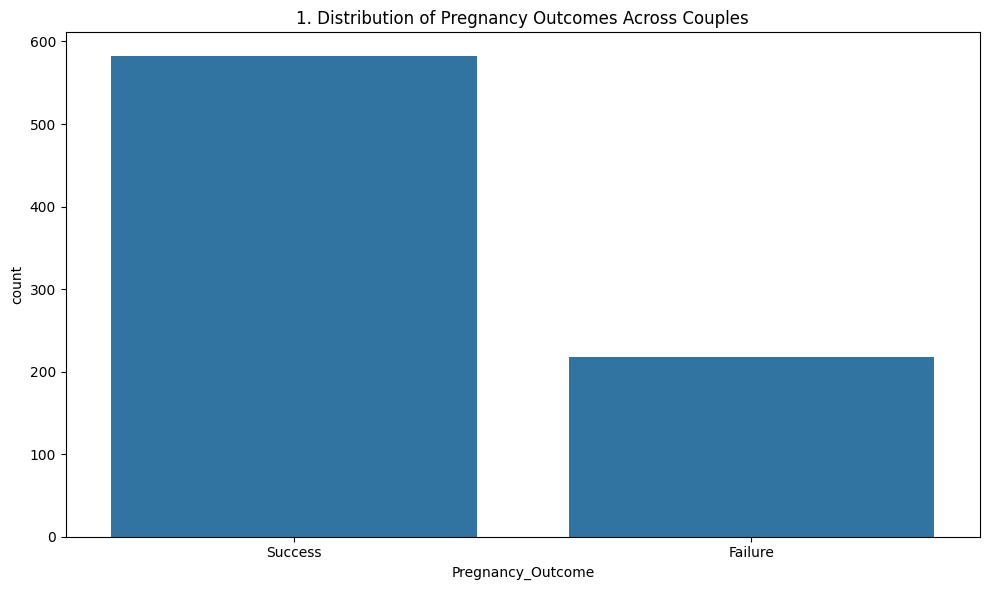

In [14]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Pregnancy_Outcome')
plt.title(f'{plot_no}. Distribution of Pregnancy Outcomes Across Couples')
show_fig()
plot_no += 1

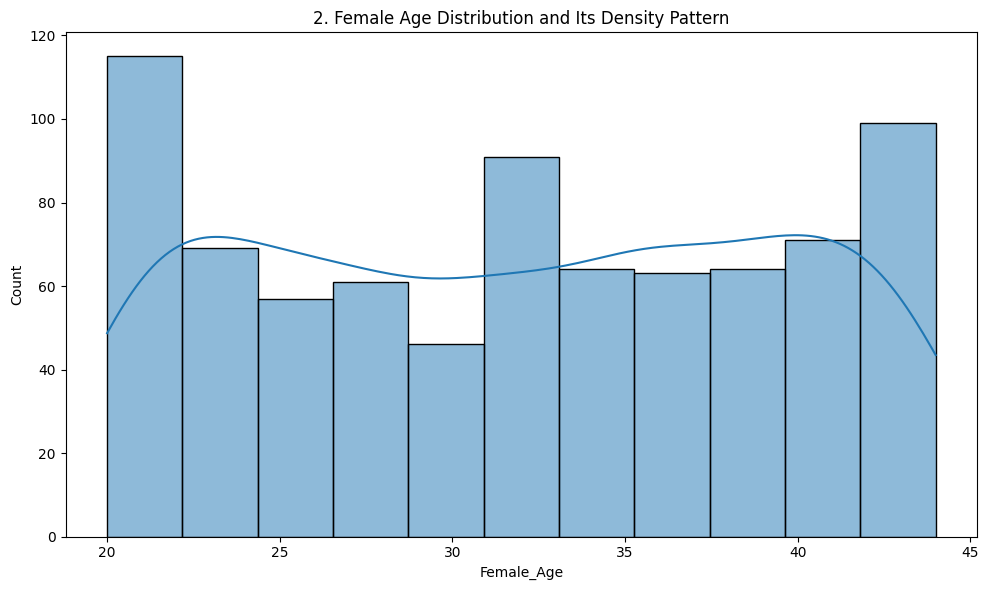

In [15]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Female_Age'], kde=True)
plt.title(f'{plot_no}. Female Age Distribution and Its Density Pattern')
show_fig()
plot_no += 1

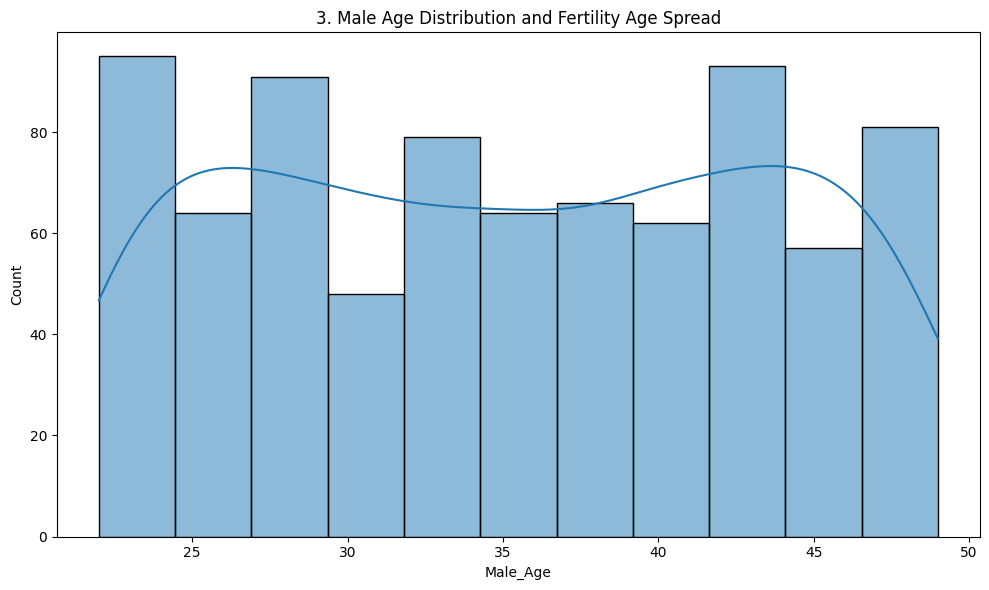

In [16]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Male_Age'], kde=True)
plt.title(f'{plot_no}. Male Age Distribution and Fertility Age Spread')
show_fig()
plot_no += 1

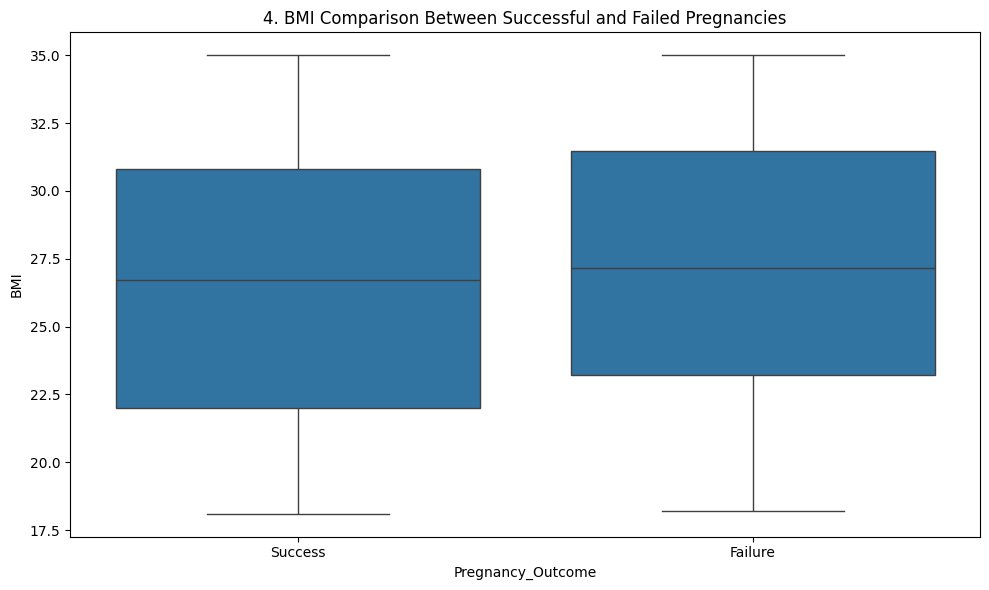

In [17]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Pregnancy_Outcome', y='BMI')
plt.title(f'{plot_no}. BMI Comparison Between Successful and Failed Pregnancies')
show_fig()
plot_no += 1

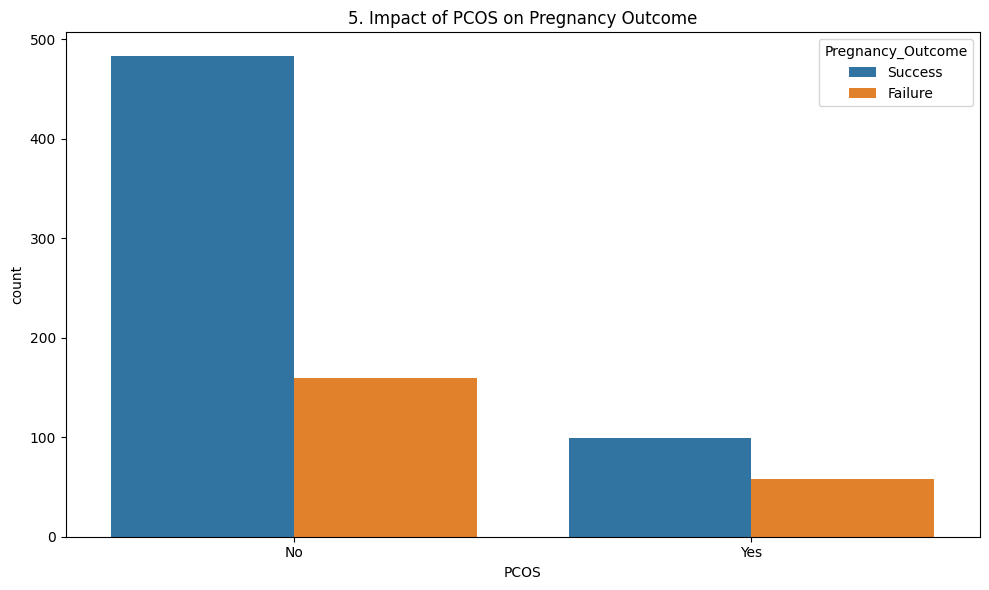

In [18]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='PCOS', hue='Pregnancy_Outcome')
plt.title(f'{plot_no}. Impact of PCOS on Pregnancy Outcome')
show_fig()
plot_no += 1

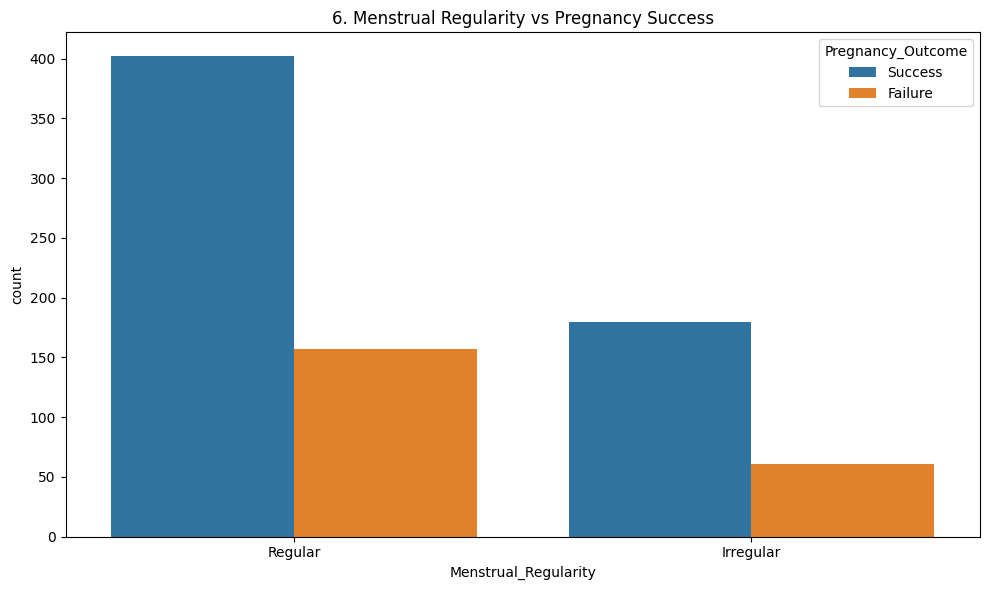

In [19]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Menstrual_Regularity', hue='Pregnancy_Outcome')
plt.title(f'{plot_no}. Menstrual Regularity vs Pregnancy Success')
show_fig()
plot_no += 1

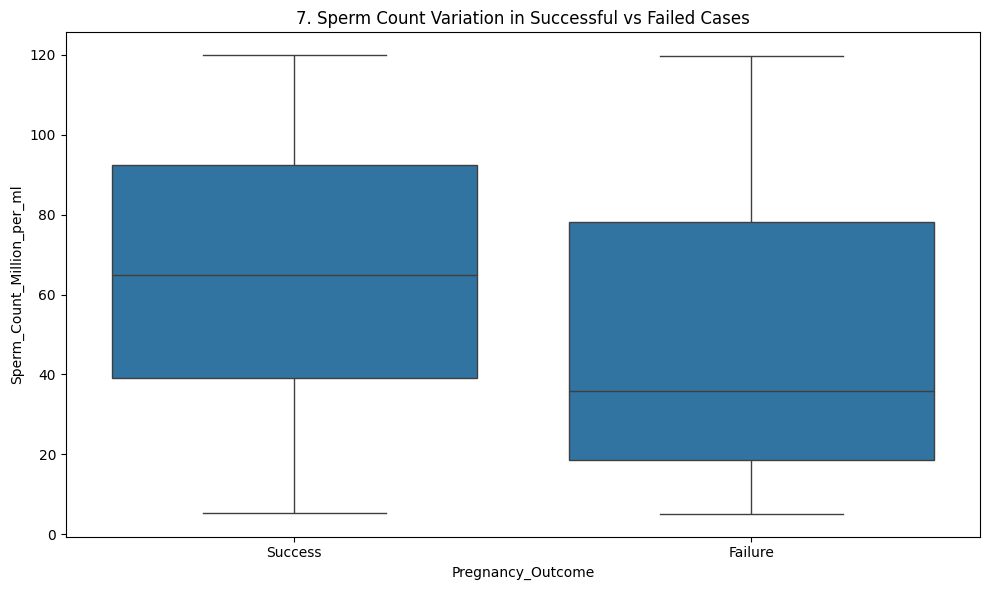

In [20]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Pregnancy_Outcome', y='Sperm_Count_Million_per_ml')
plt.title(f'{plot_no}. Sperm Count Variation in Successful vs Failed Cases')
show_fig()
plot_no += 1

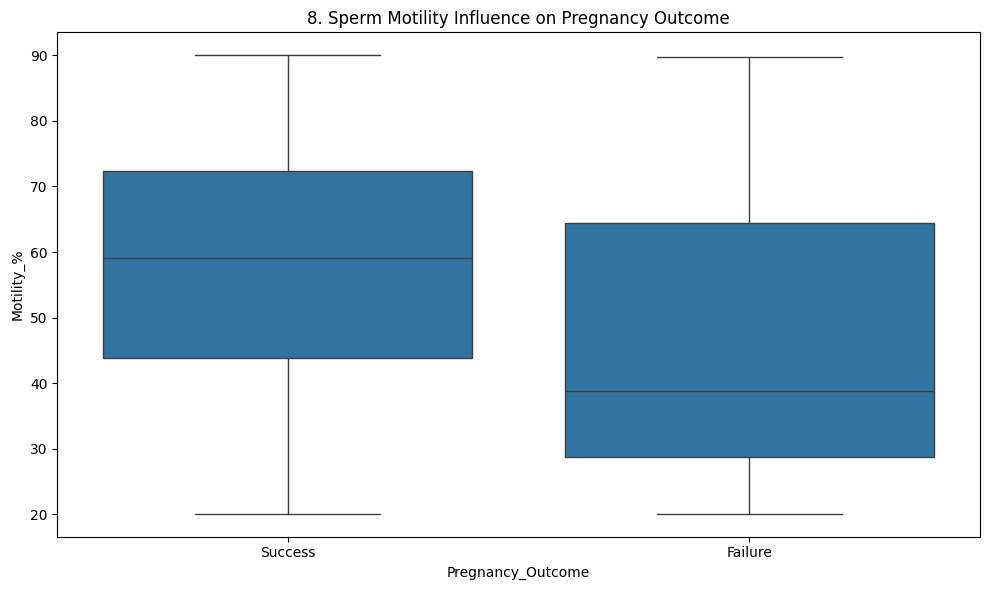

In [21]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Pregnancy_Outcome', y='Motility_%')
plt.title(f'{plot_no}. Sperm Motility Influence on Pregnancy Outcome')
show_fig()
plot_no += 1

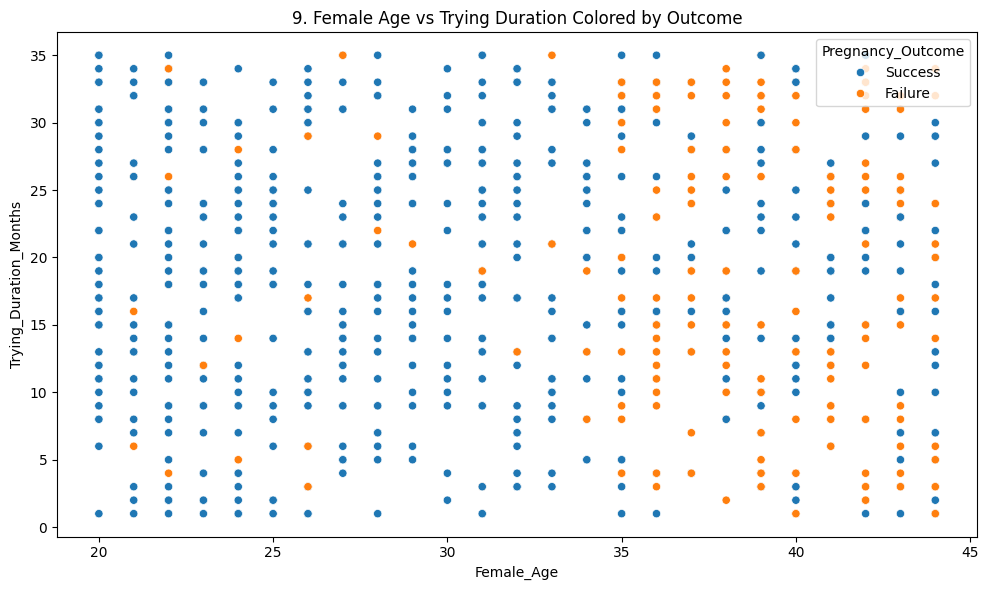

In [22]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Female_Age', y='Trying_Duration_Months', hue='Pregnancy_Outcome')
plt.title(f'{plot_no}. Female Age vs Trying Duration Colored by Outcome')
show_fig()
plot_no += 1

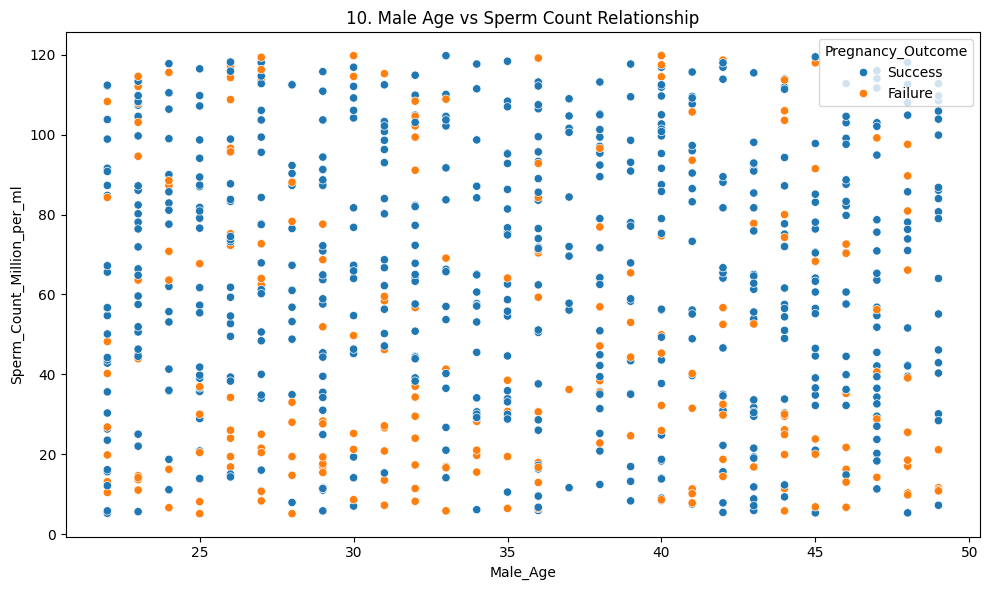

In [23]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Male_Age', y='Sperm_Count_Million_per_ml', hue='Pregnancy_Outcome')
plt.title(f'{plot_no}. Male Age vs Sperm Count Relationship')
show_fig()
plot_no += 1

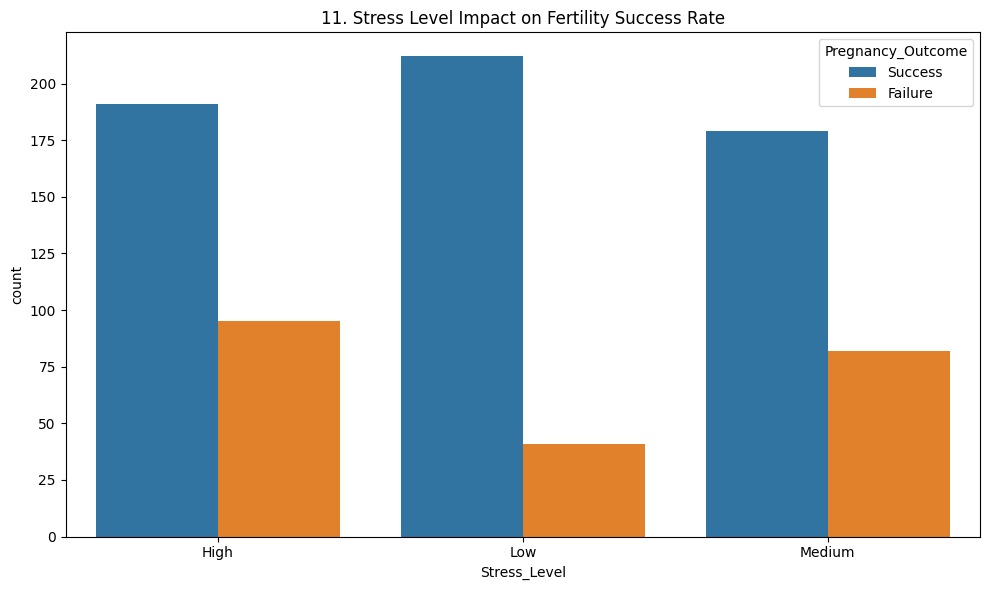

In [24]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Stress_Level', hue='Pregnancy_Outcome')
plt.title(f'{plot_no}. Stress Level Impact on Fertility Success Rate')
show_fig()
plot_no += 1

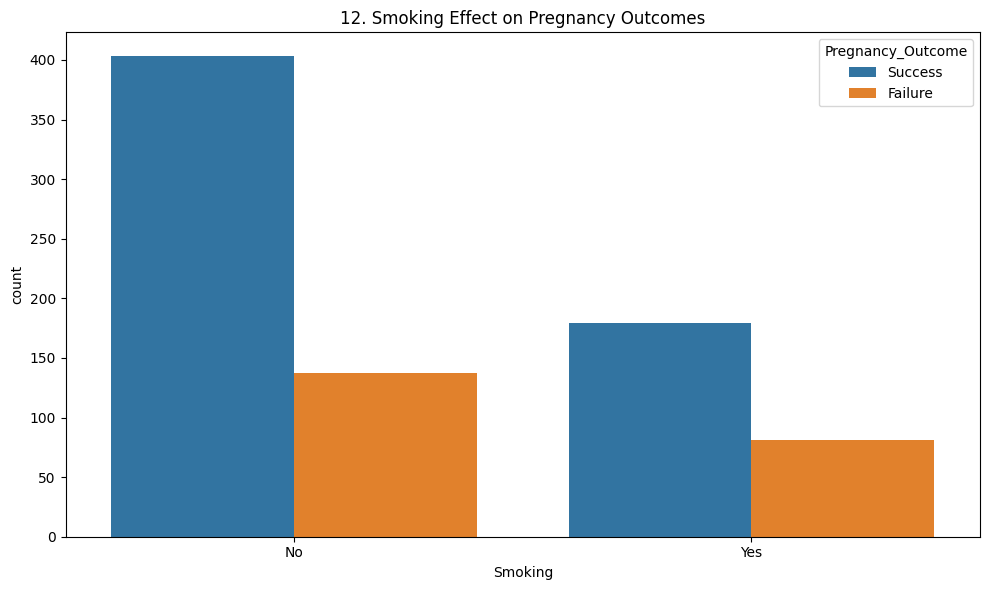

In [25]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Smoking', hue='Pregnancy_Outcome')
plt.title(f'{plot_no}. Smoking Effect on Pregnancy Outcomes')
show_fig()
plot_no += 1

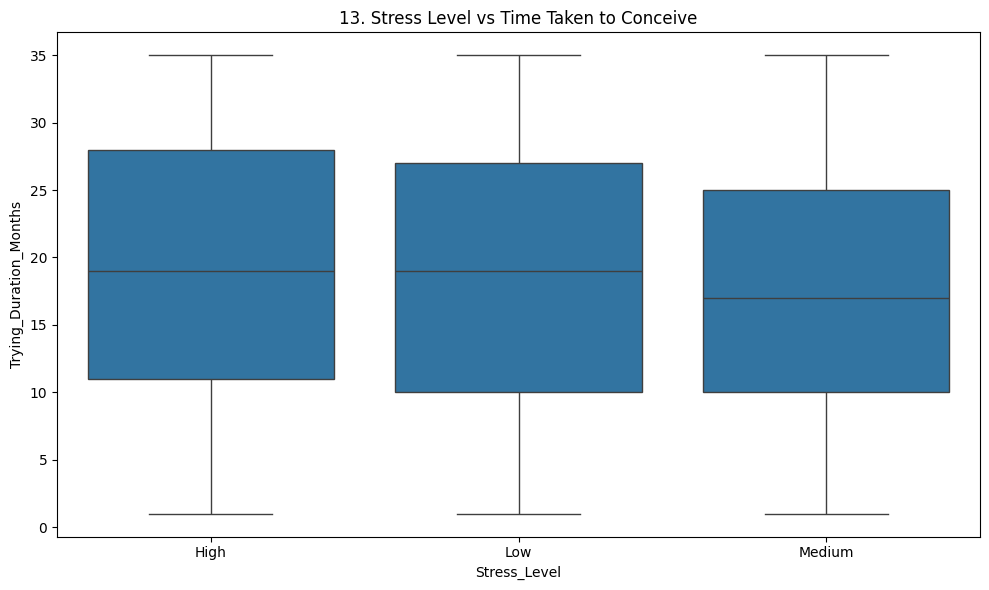

In [26]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Stress_Level', y='Trying_Duration_Months')
plt.title(f'{plot_no}. Stress Level vs Time Taken to Conceive')
show_fig()
plot_no += 1

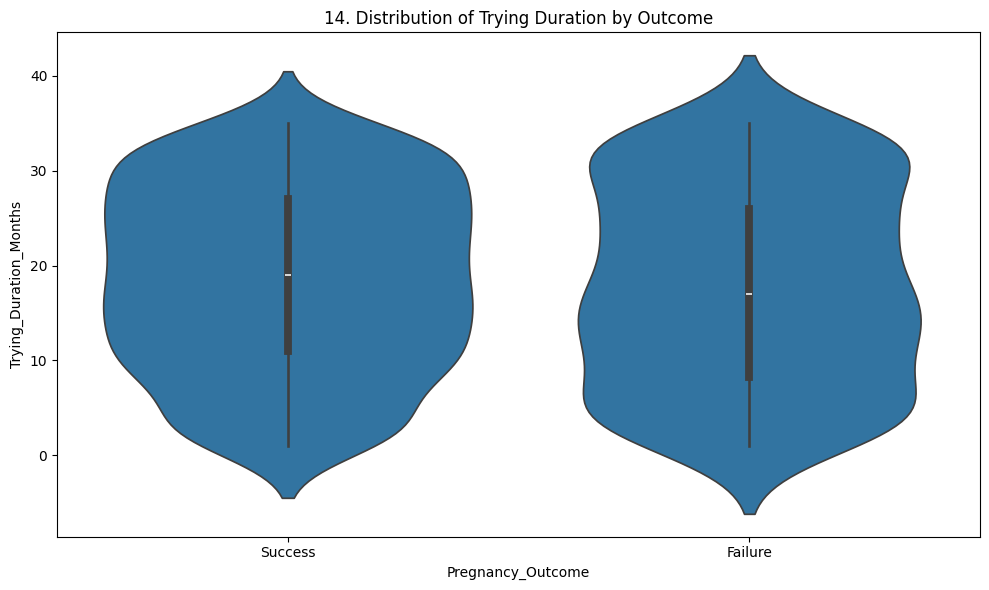

In [27]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='Pregnancy_Outcome', y='Trying_Duration_Months')
plt.title(f'{plot_no}. Distribution of Trying Duration by Outcome')
show_fig()
plot_no += 1

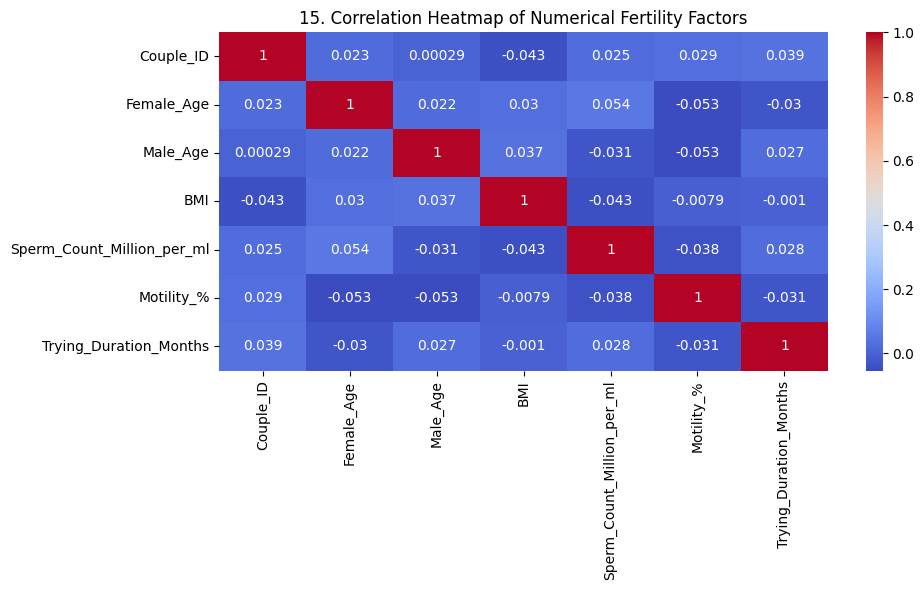

In [28]:
fig = plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Fertility Factors')
show_fig()
plot_no += 1

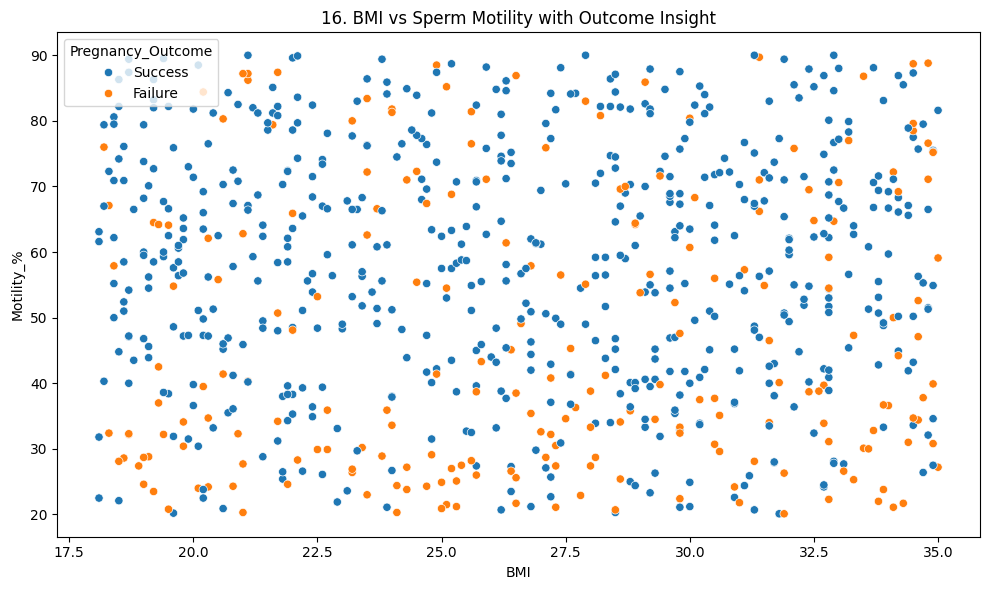

In [29]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='BMI', y='Motility_%', hue='Pregnancy_Outcome')
plt.title(f'{plot_no}. BMI vs Sperm Motility with Outcome Insight')
show_fig()
plot_no += 1

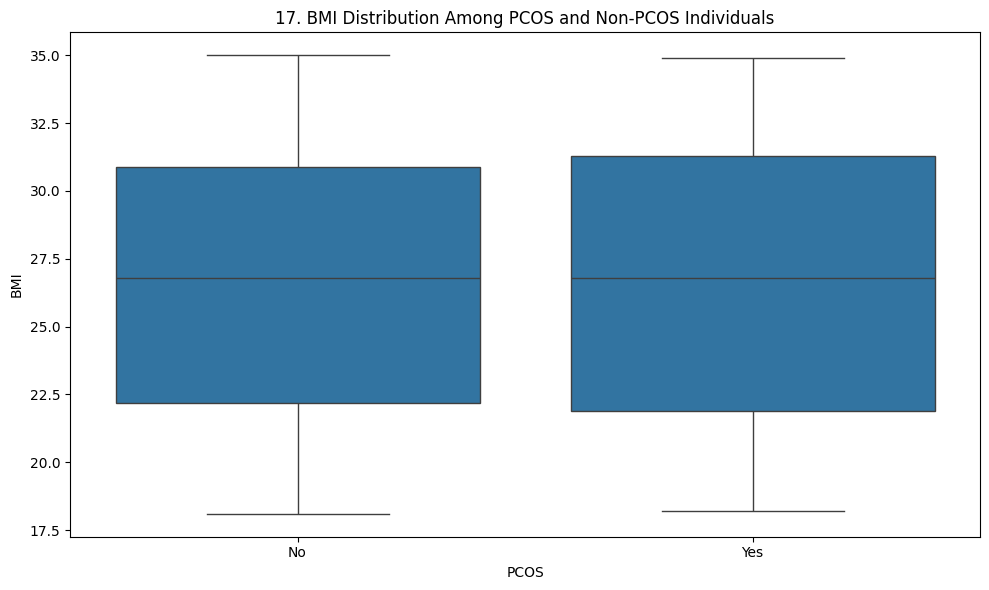

In [30]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='PCOS', y='BMI')
plt.title(f'{plot_no}. BMI Distribution Among PCOS and Non-PCOS Individuals')
show_fig()
plot_no += 1

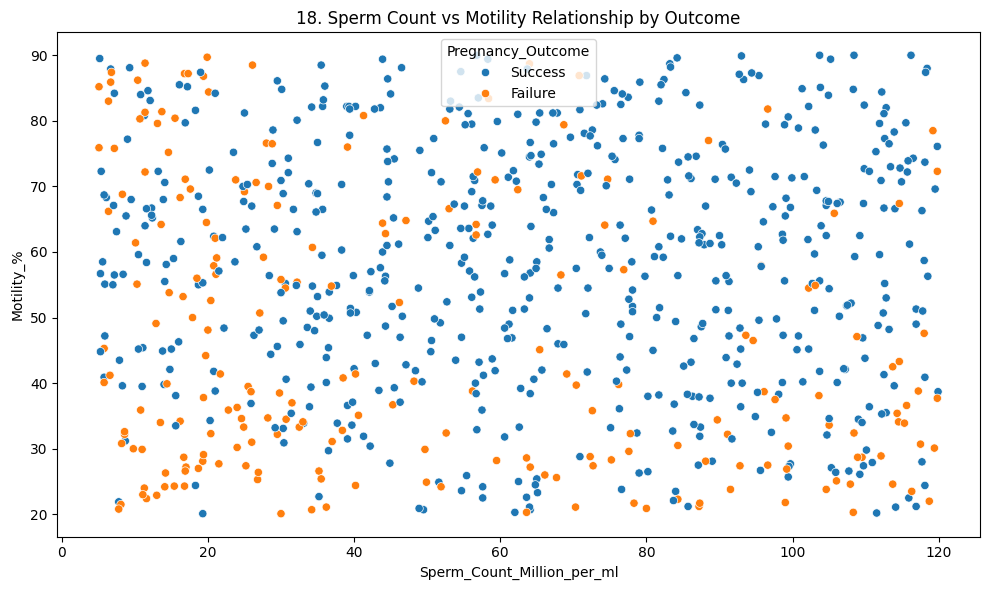

In [31]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Sperm_Count_Million_per_ml', y='Motility_%', hue='Pregnancy_Outcome')
plt.title(f'{plot_no}. Sperm Count vs Motility Relationship by Outcome')
show_fig()
plot_no += 1

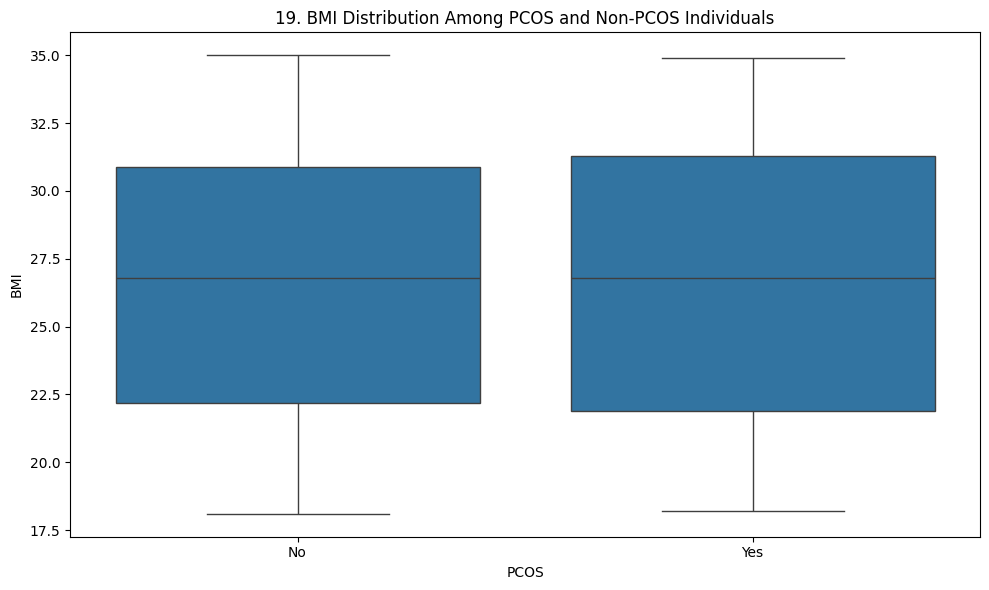

In [32]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='PCOS', y='BMI')
plt.title(f'{plot_no}. BMI Distribution Among PCOS and Non-PCOS Individuals')
show_fig()
plot_no += 1

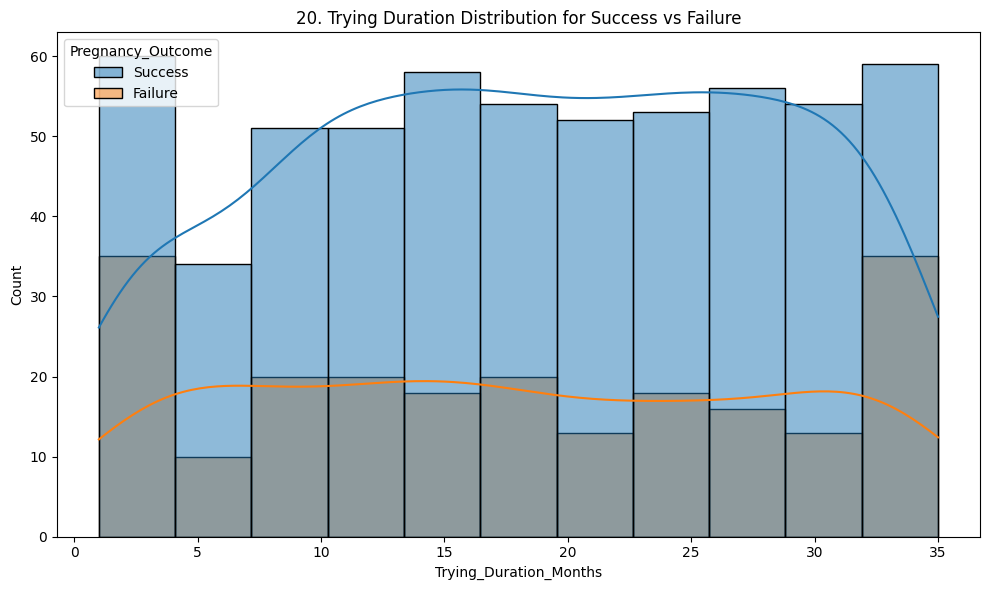

In [33]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Trying_Duration_Months', hue='Pregnancy_Outcome', kde=True)
plt.title(f'{plot_no}. Trying Duration Distribution for Success vs Failure')
show_fig()
plot_no += 1

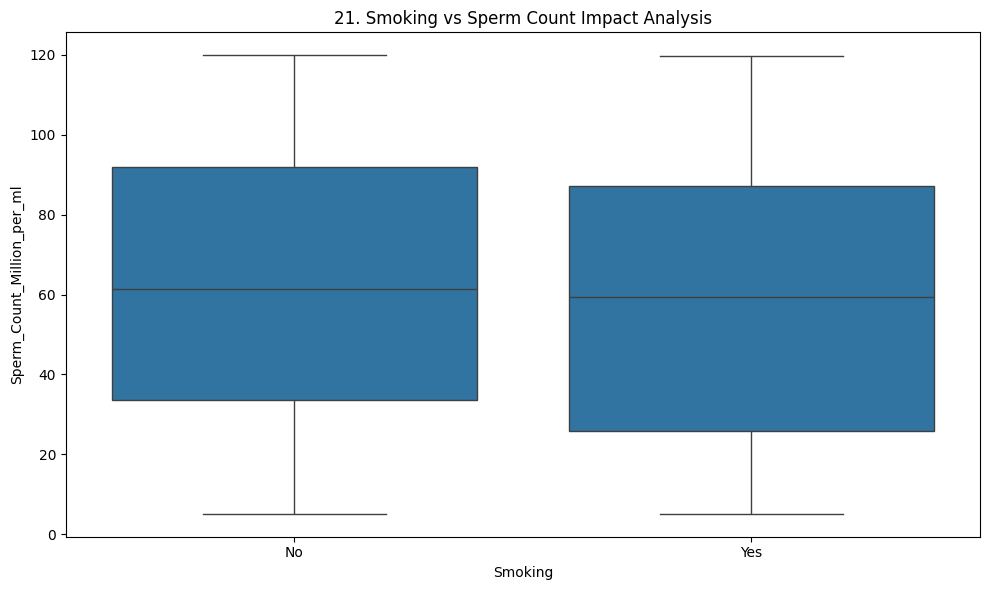

In [34]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Smoking', y='Sperm_Count_Million_per_ml')
plt.title(f'{plot_no}. Smoking vs Sperm Count Impact Analysis')
show_fig()
plot_no += 1

# Model Training

## copy dataframe to avoid modifying original

In [35]:
data = df.copy()

## encode categorical columns

In [36]:
le = LabelEncoder()
for col in ['Menstrual_Regularity','PCOS','Stress_Level','Smoking','Pregnancy_Outcome']:
    data[col] = le.fit_transform(data[col])

## split features and target

In [37]:
X = data.drop(['Couple_ID','Pregnancy_Outcome'], axis=1)
y = data['Pregnancy_Outcome']

## train-test split

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## scale features

In [39]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## train Logistic Regression model

In [40]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

## predictions

In [41]:
y_pred = model.predict(X_test)

## print accuracy

In [42]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8375


## print classification report

In [43]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.55      0.65        44
           1       0.85      0.95      0.89       116

    accuracy                           0.84       160
   macro avg       0.82      0.75      0.77       160
weighted avg       0.83      0.84      0.83       160



## confusion matrix plot

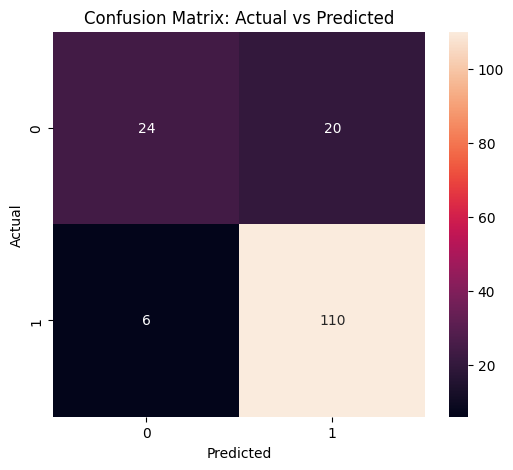

In [44]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix: Actual vs Predicted')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()